<a href="https://colab.research.google.com/github/tanyagupta12/Prostate_Cancer_Detection_Machine_learning-/blob/main/Cancer_Dectection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Data Cleaning
import pandas as pd
import numpy as np

df = pd.read_csv('Prostate_cancer.csv')

#handling missing values
df.dropna(inplace=True) #remove rows with missing values

#removing duplicate rows
df.drop_duplicates(inplace=True)

print(df.head())
print(df.info())

   id diagnosis_result  radius  texture  perimeter  area  smoothness  \
0   1                M      23       12        151   954       0.143   
1   2                B       9       13        133  1326       0.143   
2   3                M      21       27        130  1203       0.125   
3   4                M      14       16         78   386       0.070   
4   5                M       9       19        135  1297       0.141   

   compactness  symmetry  fractal_dimension  
0        0.278     0.242              0.079  
1        0.079     0.181              0.057  
2        0.160     0.207              0.060  
3        0.284     0.260              0.097  
4        0.133     0.181              0.059  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 100 non-null    int64  
 1   diagnosis_result   100 non-null    obj

In [ ]:
#Data Normalization
import pandas as pd

csv_file = 'Prostate_cancer.csv'
df = pd.read_csv(csv_file)

columns_to_normalize = ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness', 'symmetry', 'fractal_dimension']

#min-max scaling
for column in columns_to_normalize:
    min_value = df[column].min()
    max_value = df[column].max()
    df[column] = (df[column] - min_value) / (max_value - min_value)

#Z-score normalization
for column in columns_to_normalize:
    mean = df[column].mean()
    std = df[column].std()
    df[column] = (df[column] - mean) / std

normalized_csv_file = 'normalized_data.csv'
df.to_csv(normalized_csv_file, index=False)

print(f"Normalized data saved to {normalized_csv_file}")

Normalized data saved to normalized_data.csv


In [ ]:
#Data Transformation
import pandas as pd

csv_file = 'normalized_data.csv'
df = pd.read_csv(csv_file)

categorical_columns = ['diagnosis_result']

#perform encoding for the selected categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, prefix=categorical_columns)

transformed_csv_file = 'transformed_data.csv'
df_encoded.to_csv(transformed_csv_file, index=False)

print(f"Transformed data saved to {transformed_csv_file}")


Transformed data saved to transformed_data.csv


Dataset : (100, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 100 non-null    int64  
 1   diagnosis_result   100 non-null    object 
 2   radius             100 non-null    int64  
 3   texture            100 non-null    int64  
 4   perimeter          100 non-null    int64  
 5   area               100 non-null    int64  
 6   smoothness         100 non-null    float64
 7   compactness        100 non-null    float64
 8   symmetry           100 non-null    float64
 9   fractal_dimension  100 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 7.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 100 non-null  

<ipython-input-10-31b5fee645e2>:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[['diagnosis_result']] = df[['diagnosis_result']].apply(pd.to_numeric, errors ='ignore')


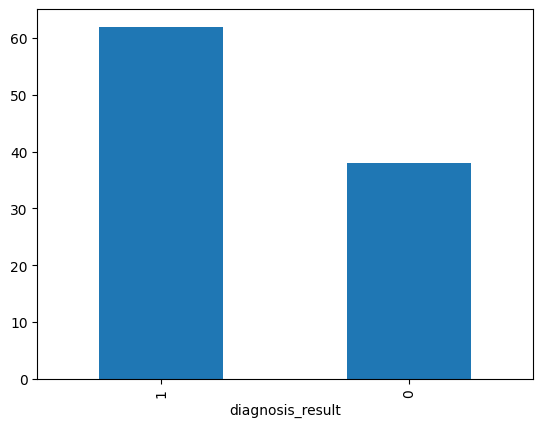

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


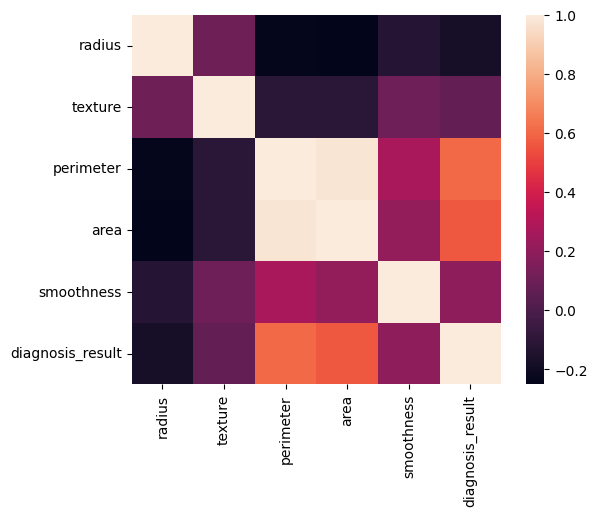

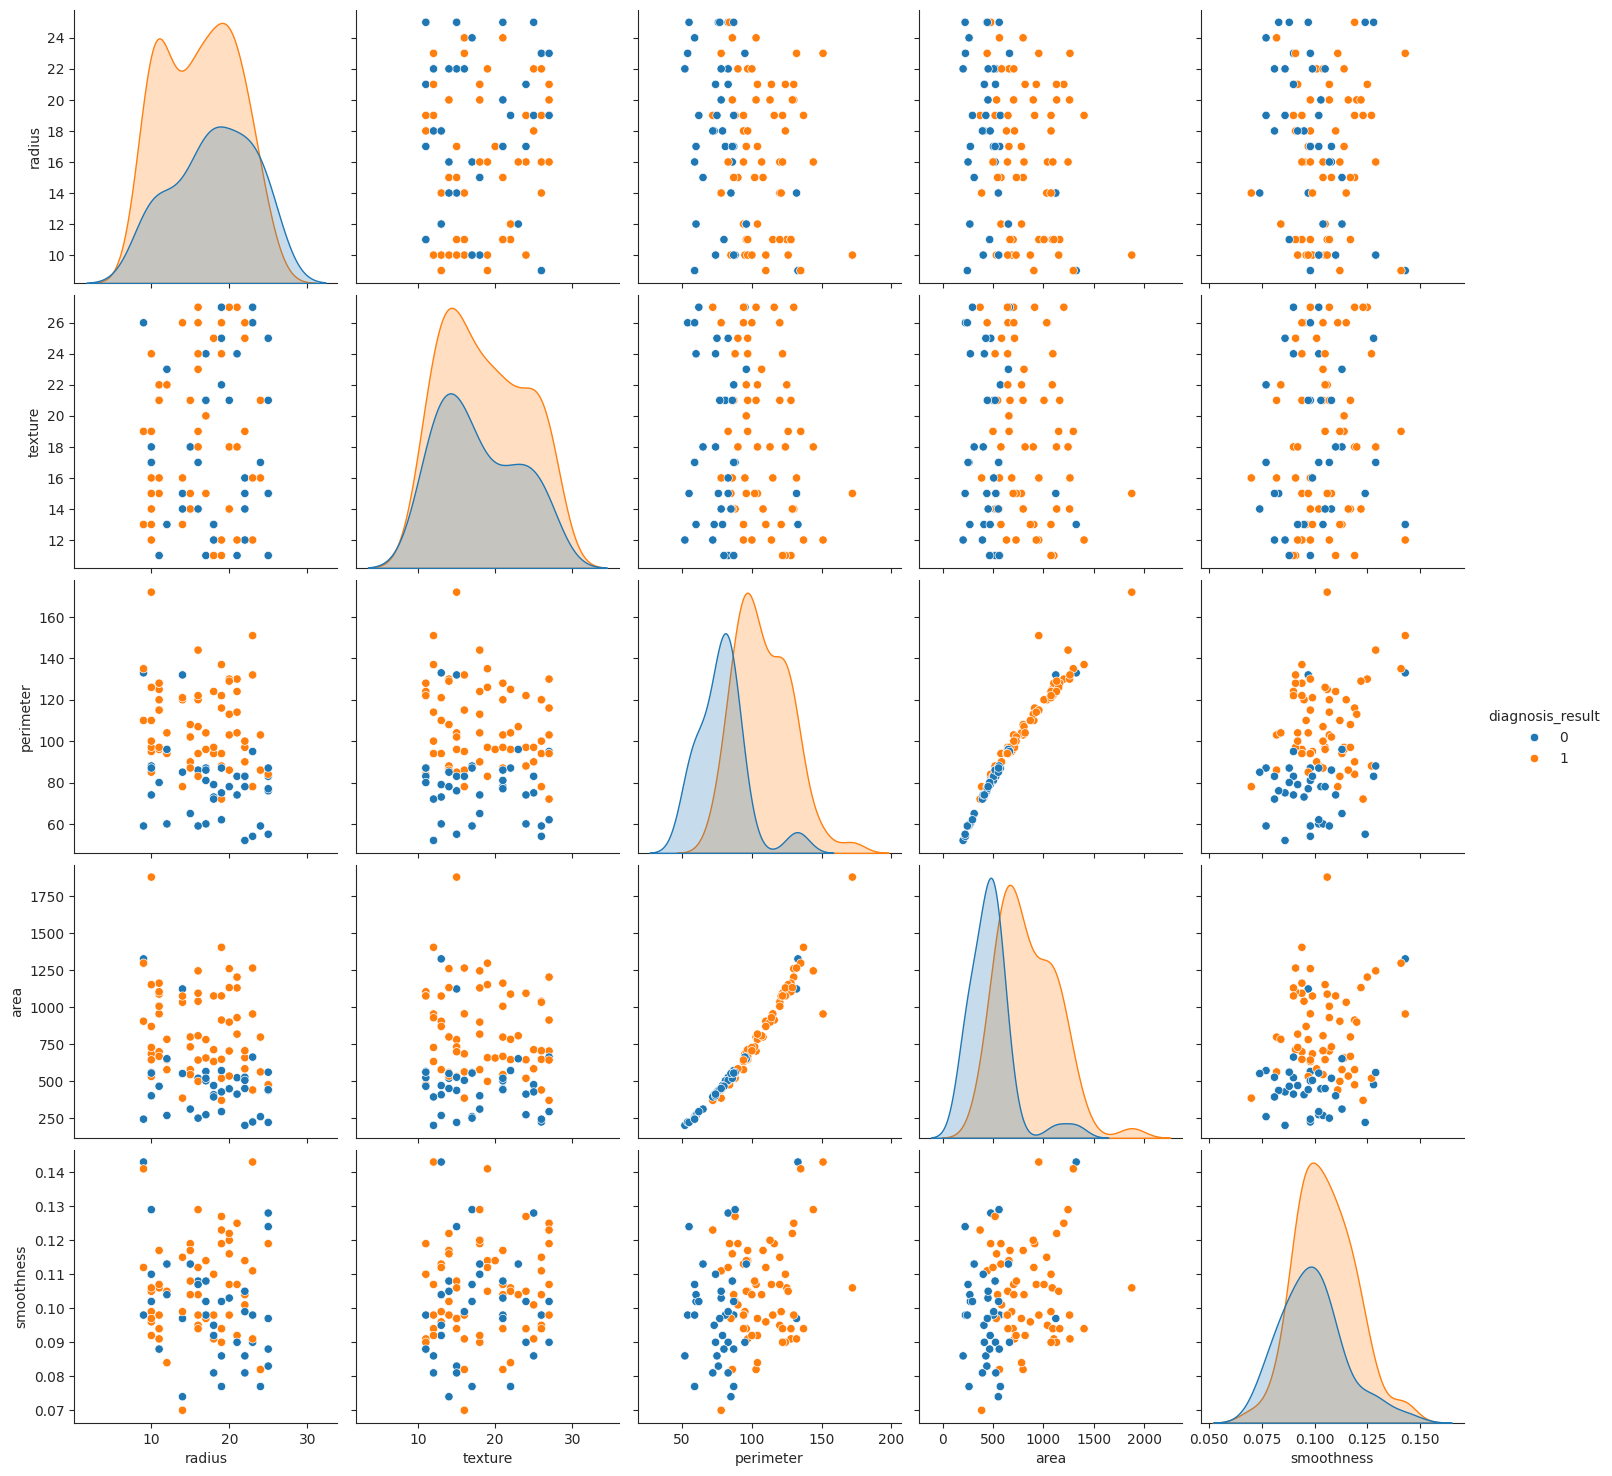

X train shape:  (80, 5)
Y train shape:  (80,)
X test shape:  (20, 5)
Y test shape:  (20,)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('Prostate_cancer.csv')
print('Dataset :',df.shape)
x = df.iloc[:, [0, 1, 2, 3]].values
df.info()
df[0:10]

df['diagnosis_result'] = df['diagnosis_result'].replace(['B'],'0')
df['diagnosis_result'] = df['diagnosis_result'].replace(['M'],'1')

df[['diagnosis_result']] = df[['diagnosis_result']].apply(pd.to_numeric, errors ='ignore')
df.info()

df['diagnosis_result'].value_counts()

df.diagnosis_result.value_counts()[0:30].plot(kind='bar')
plt.show()

df = df[['radius','texture','perimeter','area', 'smoothness','diagnosis_result']] #Subsetting the data
cor = df.corr() #Calculate the correlation of the above variables
sns.heatmap(cor, square = True)

sns.set_style("ticks")
sns.pairplot(df,hue="diagnosis_result",size=3);
plt.show()

from sklearn.model_selection import train_test_split
Y = df['diagnosis_result']
X = df.drop(columns=['diagnosis_result'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=9)

print('X train shape: ', X_train.shape)
print('Y train shape: ', Y_train.shape)
print('X test shape: ', X_test.shape)
print('Y test shape: ', Y_test.shape)


X train shape:  (80, 5)
Y train shape:  (80,)
X test shape:  (20, 5)
Y test shape:  (20,)


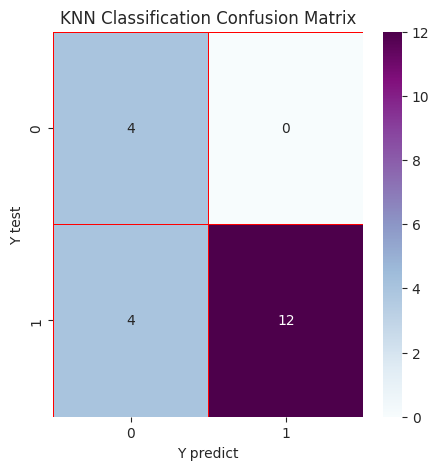

0.8
Average precision-recall score: 0.95


In [ ]:
#KNN Algorithm
from sklearn.model_selection import train_test_split
Y = df['diagnosis_result']
X = df.drop(columns=['diagnosis_result'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=9)

print('X train shape: ', X_train.shape)
print('Y train shape: ', Y_train.shape)
print('X test shape: ', X_test.shape)
print('Y test shape: ', Y_test.shape)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# We define the model
knncla = KNeighborsClassifier(n_neighbors=5,n_jobs=-1)

# We train model
knncla.fit(X_train, Y_train)

# We predict target values
Y_predict6 = knncla.predict(X_test)

# The confusion matrix
knncla_cm = confusion_matrix(Y_test, Y_predict6)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(knncla_cm, annot=True, linewidth=0.7, linecolor='red', fmt='g', ax=ax, cmap="BuPu")
plt.title('KNN Classification Confusion Matrix')
plt.xlabel('Y predict')
plt.ylabel('Y test')
plt.show()

# Test score
score_knncla= knncla.score(X_test, Y_test)
print(score_knncla)

from sklearn.metrics import average_precision_score
average_precision = average_precision_score(Y_test, Y_predict6)

print('Average precision-recall score: {0:0.2f}'.format(average_precision))

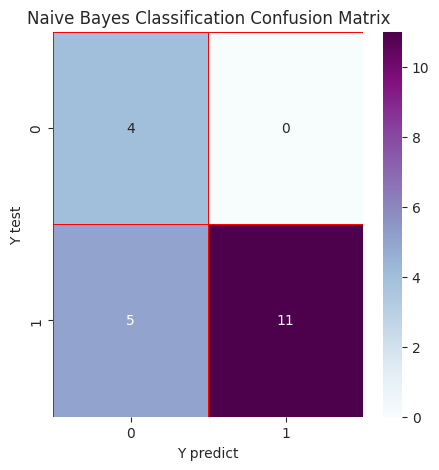

0.75
Average precision-recall score: 0.94


In [ ]:
#Naive Bayes Algorithm
from sklearn.naive_bayes import GaussianNB

# We define the model
nbcla = GaussianNB()

# We train model
nbcla.fit(X_train, Y_train)

# We predict target values
Y_predict3 = nbcla.predict(X_test)

# The confusion matrix
nbcla_cm = confusion_matrix(Y_test, Y_predict3)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(nbcla_cm, annot=True, linewidth=0.7, linecolor='red', fmt='g', ax=ax, cmap="BuPu")
plt.title('Naive Bayes Classification Confusion Matrix')
plt.xlabel('Y predict')
plt.ylabel('Y test')
plt.show()

# Test score
score_nbcla = nbcla.score(X_test, Y_test)
print(score_nbcla)

#precision and recall
from sklearn.metrics import average_precision_score
average_precision = average_precision_score(Y_test, Y_predict3)

print('Average precision-recall score: {0:0.2f}'.format(average_precision))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


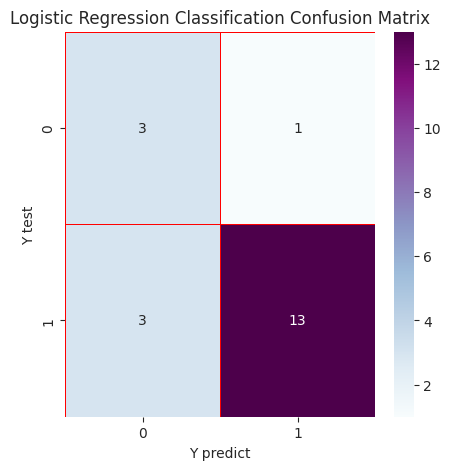

0.8
Average precision-recall score: 0.90


In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

# We defining the model
logreg = LogisticRegression(C=10)

# We train the model
logreg.fit(X_train, Y_train)

# We predict target values
Y_predict1 = logreg.predict(X_test)

from sklearn.metrics import confusion_matrix
import seaborn as sns

logreg_cm = confusion_matrix(Y_test, Y_predict1)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(logreg_cm, annot=True, linewidth=0.7, linecolor='red', fmt='g', ax=ax, cmap="BuPu")
plt.title('Logistic Regression Classification Confusion Matrix')
plt.xlabel('Y predict')
plt.ylabel('Y test')
plt.show()

# Test score
score_logreg = logreg.score(X_test, Y_test)
print(score_logreg)

#precision and recall
from sklearn.metrics import average_precision_score
average_precision = average_precision_score(Y_test, Y_predict1)

print('Average precision-recall score: {0:0.2f}'.format(average_precision))

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Load a sample prostate cancer dataset (replace with your own data)
data = pd.read_csv('Prostate_cancer.csv')
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Encode categorical variables (if any)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(Y)

# Standardize/Normalize feature values (if needed)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into a training set and a testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a KNN classifier (you can adjust the number of neighbors)
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Perform k-fold cross-validation (e.g., 5-fold)
k = 5
scores = cross_val_score(knn_classifier, X_train, y_train, cv=k, scoring='accuracy')

# Print cross-validation results
print("Cross-validation results:")
for i, score in enumerate(scores):
    print(f"Fold {i+1}: Accuracy = {score:.2f}")

# Calculate the average accuracy across all folds
mean_accuracy = np.mean(scores)
print(f"Mean Accuracy: {mean_accuracy:.2f}")

# Train the final model on the entire training dataset
knn_classifier.fit(X_train, y_train)

# Evaluate the model on the test set
test_accuracy = knn_classifier.score(X_test, y_test)
print(f"Test Set Accuracy: {test_accuracy:.2f}")


Cross-validation results:
Fold 1: Accuracy = 0.69
Fold 2: Accuracy = 0.88
Fold 3: Accuracy = 0.94
Fold 4: Accuracy = 0.69
Fold 5: Accuracy = 0.88
Mean Accuracy: 0.81
Test Set Accuracy: 0.80
